# Task 1: Titanic Data Cleaning and Preprocessing

This notebook walks through a modular data cleaning and preprocessing pipeline for the Titanic dataset, featuring stratified train-test splitting to prevent data leakage, duplicate checks, group-wise median imputation, one-hot encoding, outlier capping, and standardization.

## 1. Imports and Configuration

In [1]:
import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

## 2. Load Dataset and Check for Duplicates

In [2]:
# Dataset path
DATASET_PATH = '../dataset/Titanic-Dataset.csv'

df = pd.read_csv(DATASET_PATH)
print(f"Loaded raw Titanic Dataset. Shape: {df.shape}")

# Check duplicates
duplicates_count = df.duplicated().sum()
print(f"Checking duplicate rows: found {duplicates_count} duplicates.")
if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Removed duplicates. New shape: {df.shape}")
df.head()

Loaded raw Titanic Dataset. Shape: (891, 12)
Checking duplicate rows: found 0 duplicates.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Train-Validation Split (Preventing Data Leakage)

In [3]:
# Split dataset (80% Train, 20% Validation)
# Stratify on Survived to maintain balanced class distributions
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Survived'])
print(f"Split data: Train shape={train_df.shape}, Validation shape={val_df.shape}")

Split data: Train shape=(712, 12), Validation shape=(179, 12)


## 4. Imputation and Outlier Capping Parameters

In [4]:
# Define mapping constants
standard_titles = ['Mr', 'Mrs', 'Miss', 'Master', 'Rare']
title_mapping = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}

# Fit the preprocessing pipeline on training data
# 1. Age imputation group-wise medians
age_group_medians = train_df.groupby(['Pclass', 'Sex'])['Age'].median().to_dict()
age_overall_median = train_df['Age'].median()

# 2. Embarked mode
embarked_mode = train_df['Embarked'].mode()[0]

# 3. Outlier Bounds (Age and Fare)
imputed_age = train_df.apply(
    lambda row: age_group_medians.get((row['Pclass'], row['Sex']), age_overall_median) 
    if pd.isnull(row['Age']) else row['Age'], axis=1
)
Q1_age = imputed_age.quantile(0.25)
Q3_age = imputed_age.quantile(0.75)
IQR_age = Q3_age - Q1_age
age_lower = max(0, Q1_age - 1.5 * IQR_age)
age_upper = Q3_age + 1.5 * IQR_age

Q1_fare = train_df['Fare'].quantile(0.25)
Q3_fare = train_df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
fare_lower = max(0, Q1_fare - 1.5 * IQR_fare)
fare_upper = Q3_fare + 1.5 * IQR_fare

print(f"Age Outlier bounds: {age_lower} to {age_upper}")
print(f"Fare Outlier bounds: {fare_lower} to {fare_upper}")

Age Outlier bounds: 0 to 60.25
Fare Outlier bounds: 0 to 65.6563


## 5. Fit Standard Scaler on Training Features

In [5]:
# Construct temporary training frame to fit scaler
temp_df = train_df.copy()
temp_df['Age'] = imputed_age
temp_df['Age'] = temp_df['Age'].clip(lower=age_lower, upper=age_upper)
temp_df['Fare'] = temp_df['Fare'].clip(lower=fare_lower, upper=fare_upper)
temp_df['FamilySize'] = temp_df['SibSp'] + temp_df['Parch'] + 1

scaler = StandardScaler()
scaler.fit(temp_df[['Age', 'Fare', 'FamilySize']])
print("Fitted StandardScaler successfully on train split.")

Fitted StandardScaler successfully on train split.


## 6. Preprocessing Transform Function

In [6]:
# We store fit parameters in a dictionary
fit_params = {
    'age_group_medians': age_group_medians,
    'age_overall_median': age_overall_median,
    'embarked_mode': embarked_mode,
    'age_lower': age_lower,
    'age_upper': age_upper,
    'fare_lower': fare_lower,
    'fare_upper': fare_upper,
    'scaler': scaler
}

# Expected columns configuration (based on training features structure)
temp_df['Title'] = temp_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
temp_df['Title'] = temp_df['Title'].replace(title_mapping)
temp_df['Title'] = temp_df['Title'].apply(lambda x: x if x in standard_titles else 'Mr')
temp_df_encoded = pd.get_dummies(temp_df, columns=['Sex', 'Embarked', 'Title'], drop_first=True, dtype=int)
columns_to_drop = ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin']
temp_df_encoded = temp_df_encoded.drop(columns=[col for col in columns_to_drop if col in temp_df_encoded.columns], errors='ignore')
fit_params['expected_columns'] = list(temp_df_encoded.columns)

def transform_pipeline(df, fit_params):
    transformed_df = df.copy()
    transformed_df['HasCabin'] = transformed_df['Cabin'].notnull().astype(int)
    transformed_df['Cabin'] = transformed_df['Cabin'].fillna('Unknown')
    
    group_medians = fit_params['age_group_medians']
    overall_median = fit_params['age_overall_median']
    transformed_df['Age'] = transformed_df.apply(
        lambda row: group_medians.get((row['Pclass'], row['Sex']), overall_median) 
        if pd.isnull(row['Age']) else row['Age'], axis=1
    )
    
    transformed_df['Embarked'] = transformed_df['Embarked'].fillna(fit_params['embarked_mode'])
    transformed_df['Age'] = transformed_df['Age'].clip(lower=fit_params['age_lower'], upper=fit_params['age_upper'])
    transformed_df['Fare'] = transformed_df['Fare'].clip(lower=fit_params['fare_lower'], upper=fit_params['fare_upper'])
    
    transformed_df['Title'] = transformed_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    transformed_df['Title'] = transformed_df['Title'].replace(title_mapping)
    transformed_df['Title'] = transformed_df['Title'].apply(lambda x: x if x in standard_titles else 'Mr')
    
    transformed_df['FamilySize'] = transformed_df['SibSp'] + transformed_df['Parch'] + 1
    transformed_df['IsAlone'] = (transformed_df['FamilySize'] == 1).astype(int)
    
    encoded_df = pd.get_dummies(transformed_df, columns=['Sex', 'Embarked', 'Title'], drop_first=True, dtype=int)
    columns_to_drop = ['Name', 'Ticket', 'Cabin']
    encoded_df = encoded_df.drop(columns=columns_to_drop)
    
    has_passenger_id = 'PassengerId' in df.columns
    has_survived = 'Survived' in df.columns
    expected_cols = fit_params['expected_columns']
    
    encoded_df = encoded_df.reindex(columns=expected_cols, fill_value=0)
    
    scaler = fit_params['scaler']
    numerical_cols = ['Age', 'Fare', 'FamilySize']
    encoded_df[numerical_cols] = scaler.transform(encoded_df[numerical_cols])
    
    if has_passenger_id:
        encoded_df.insert(0, 'PassengerId', df['PassengerId'])
    if has_survived:
        pos = 1 if has_passenger_id else 0
        encoded_df.insert(pos, 'Survived', df['Survived'])
        
    return encoded_df

## 7. Transform Train and Validation Splits

In [7]:
# Transform train and validation sets
train_clean = transform_pipeline(train_df, fit_params)
val_clean = transform_pipeline(val_df, fit_params)
print(f"Cleaned Train shape: {train_clean.shape}")
print(f"Cleaned Validation shape: {val_clean.shape}")
train_clean.head()

Cleaned Train shape: (712, 15)
Cleaned Validation shape: (179, 15)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
692,693,1,3,-0.251837,0,0,1.587313,-0.556339,1,0,1,0,1,0,0
481,482,0,2,0.059337,0,0,-1.168780,-0.556339,1,0,1,0,1,0,0
527,528,0,1,0.837275,0,0,2.034199,-0.556339,1,0,1,0,1,0,0
855,856,1,3,-0.874187,0,1,-0.712650,0.073412,0,0,1,0,0,1,0
801,802,1,2,0.137131,1,1,0.111801,0.703162,0,0,1,0,0,1,0


## 8. Feature Correlation Heatmap

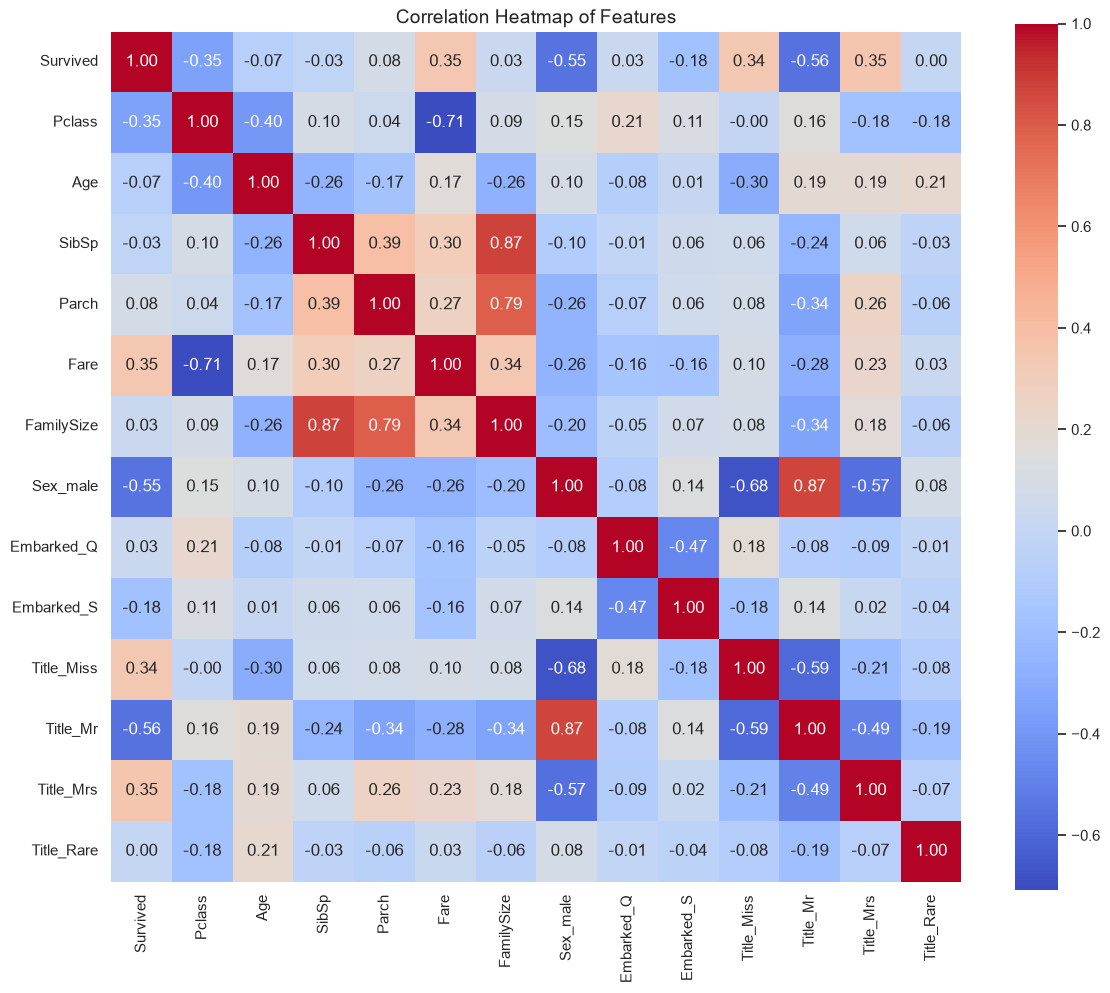

In [8]:
# Correlation matrix
plt.figure(figsize=(12, 10))
corr_cols = [col for col in train_clean.columns if col not in ['PassengerId']]
corr = train_clean[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Heatmap of Features", fontsize=14)
plt.tight_layout()
plt.show()